# Impact of $c_s^2$ on observables

Usual dark energy models assume an effective sound speed of $c_s^2 = 1$. What is the impact of another choice, *e.g.* $c_s^2 = 0$?

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import camb
import utils

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams["legend.framealpha"] = 0.0

In [2]:
# Cosmological parameters for examples
H0 = 67
omegam = 0.319
omegab = 0.049
As = 2.1e-9
ns = 0.96
tau = 0.07

dark_energy_types = ["desi_pp_mean", "wcdm"]
dark_energy_type = "desi_pp_mean"

if dark_energy_type == "desi_pp_mean":
    # DESI DR2 BAO + CMB + Pantheon+ mean
    w0 = -0.838
    wa = -0.62
elif dark_energy_type == "wcdm":
    w0 = -0.8
    wa = 0
else:
    raise Exception(f"Unsupported dark_energy_type {dark_energy_type}; supported values are {dark_energy_types}.")

# Derived parameters
h = H0/100
omegac = omegam - omegab
ombh2 = omegab*h*h
omch2 = omegac*h*h

# k, z grid for power spectrum
ks = np.logspace(-4, -0.9, 256)
redshifts = np.linspace(0, 3, 256)

In [ ]:
base_case = {"label": "$c_s^2 = 1$", "cs2_0": 1, "use_cs2": False, "alpha_K_0": 0}
cases = {
    "clust1e-1": {"label": "$c_s^2 = 10^{-1}$", "cs2_0": 1e-1, "use_cs2": False, "alpha_K_0": 0},
    "clust1e-2": {"label": "$c_s^2 = 10^{-3}$", "cs2_0": 1e-3, "use_cs2": False, "alpha_K_0": 0},
    "clust1e-3": {"label": "$c_s^2 = 10^{-5}$", "cs2_0": 1e-5, "use_cs2": False, "alpha_K_0": 0},
}

utils.get_observables(base_case, H0, ombh2, omch2, As, ns, tau, w0, wa, "ppf", 0, redshifts, ks)
for name, case in cases.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, "ppf", 0, redshifts, ks)

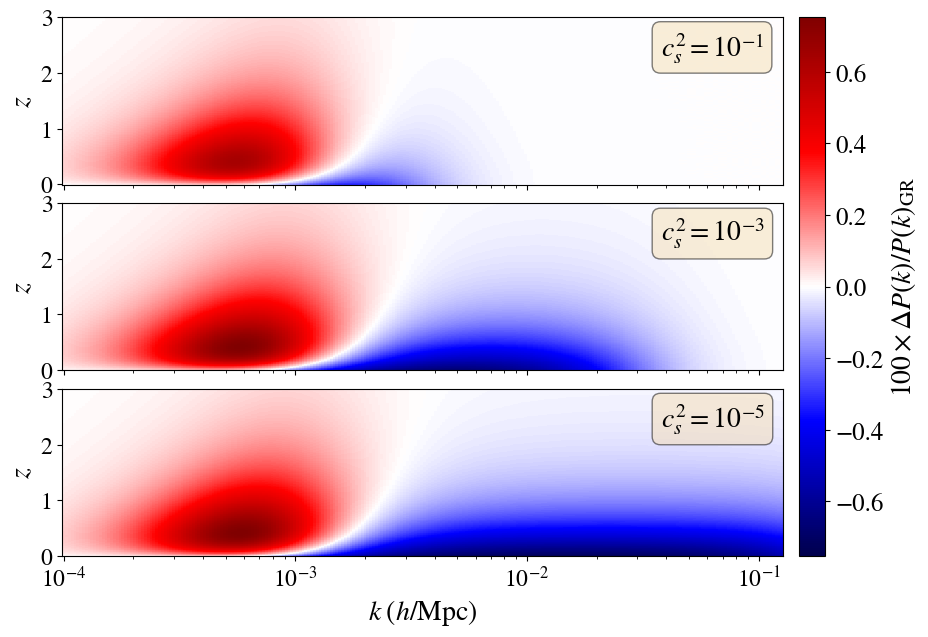

In [19]:
utils.plot_pk_differences(cases, base_case, ks, redshifts, "plots/impact_pk_ppf.png")

/home/joao/cosmo/cs2-project/observables_impact/utils.py:66: RuntimeWarning: invalid value encountered in divide
/home/joao/cosmo/cs2-project/observables_impact/utils.py:67: RuntimeWarning: invalid value encountered in divide
/home/joao/cosmo/cs2-project/observables_impact/utils.py:68: RuntimeWarning: invalid value encountered in divide


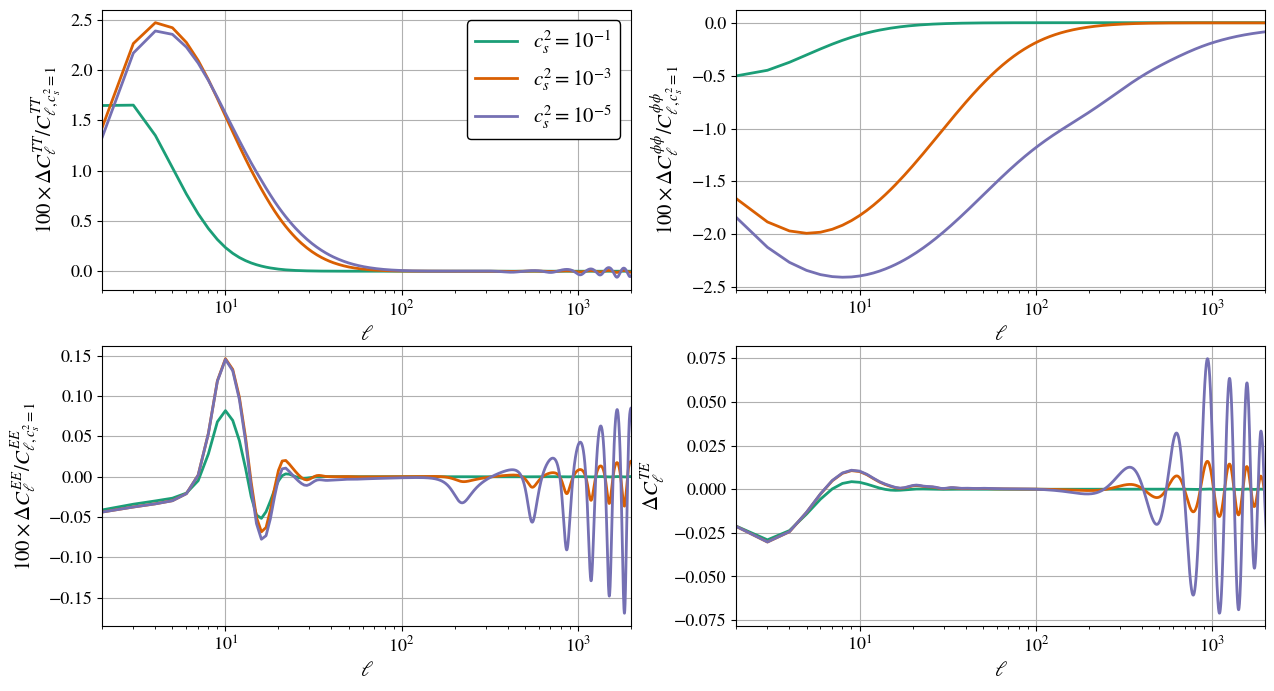

In [ ]:
utils.plot_cmb_differences(cases, base_case, "plots/impact_cmb_ppf.pdf")